In [1]:
import os 
import numpy as np
import polars as pl
import pandas as pd

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, classification_report, confusion_matrix

import seaborn as sns

In [2]:
WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/08_HepG2/'
OUTPUT_DIR = os.path.join(WORKING_DIR, 'output', 'neural_network_classification', 'all_histone')

In [3]:
def load_data(path):
    gene_pl = pl.read_parquet(path)
    return gene_pl

In [4]:
def reformat_data(df, columns):
    processed_arrays = []

    for col in columns:
        arrays = df[col].to_list()
        stacked = np.vstack(arrays)
        processed_arrays.append(stacked)

    X = np.hstack(processed_arrays)
    return X

In [5]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

In [6]:
def plot_roc_curve(y_true, y_prob, title='ROC Curve'):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()
    
    return roc_auc

In [7]:
def create_and_train_model(X, y, random_state=42):
    # Split the dataset
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.666, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

    # Create and train the model
    model = MLPClassifier(
                hidden_layer_sizes=(256, 128, 64),  # Three hidden layers
                max_iter=1000,
                activation='relu',
                solver='adam',
                random_state=42,
                verbose=True
            )
    
    model.fit(X_train, y_train)

    # Get predictions and probabilities
    train_pred = model.predict(X_train)
    train_prob = model.predict_proba(X_train)[:, 1]
    
    val_pred = model.predict(X_val)
    val_prob = model.predict_proba(X_val)[:, 1]
    
    test_pred = model.predict(X_test)
    test_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    train_metrics = classification_report(y_train, train_pred)
    val_metrics = classification_report(y_val, val_pred)
    test_metrics = classification_report(y_test, test_pred)

    # Plot confusion matrices
    print("Train Set Confusion Matrix:")
    plot_confusion_matrix(y_train, train_pred, title='Train Set Confusion Matrix')
    
    print("\nValidation Set Confusion Matrix:")
    plot_confusion_matrix(y_val, val_pred, title='Validation Set Confusion Matrix')
    
    print("\nTest Set Confusion Matrix:")
    plot_confusion_matrix(y_test, test_pred, title='Test Set Confusion Matrix')
    
    # Plot ROC curves
    print("Train Set ROC Curve:")
    train_auc = plot_roc_curve(y_train, train_prob, title='Train Set ROC Curve')
    
    print("Validation Set ROC Curve:")
    val_auc = plot_roc_curve(y_val, val_prob, title='Validation Set ROC Curve')
    
    print("Test Set ROC Curve:")
    test_auc = plot_roc_curve(y_test, test_prob, title='Test Set ROC Curve')
    
    return model, {
        'train_metrics': test_metrics,
        'validation_metrics': val_metrics,
        'test_metrics': test_metrics,
        'train_auc': train_auc,
        'validation_auc': val_auc,
        'test_auc': test_auc,
        'splits': {
            'X_train': X_train,
            'X_val': X_val,
            'X_test': X_test,
            'y_train': y_train,
            'y_val': y_val,
            'y_test': y_test
        }
    }

In [8]:
# Load dataset
gene_pl = load_data(os.path.join(WORKING_DIR, 'dataset', 'gene_w_label_value_1.parquet'))
gene_pl.head(5)

gene_id,H3K4me3,H3K4me3_count,H3K9ac,H3K9ac_count,H3K9me3,H3K9me3_count,H3K27ac,H3K27ac_count,H3K27me3,H3K27me3_count,value_1,label
str,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,f64,i32
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_000003""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_000006""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0888452,0
"""XLOC_000007""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,4.04743,1
"""XLOC_000008""","[0.0, 0.0, … 0.0]",6,"[0.0, 0.0, … 0.0]",3,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",2,"[0.0, 0.0, … 0.0]",0,26.7934,1


In [9]:
markers = ['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']

X = reformat_data(gene_pl, markers)

In [10]:
y = gene_pl['label'].to_numpy()

Iteration 1, loss = 0.60045206
Iteration 2, loss = 0.50768196
Iteration 3, loss = 0.48123692
Iteration 4, loss = 0.46284061
Iteration 5, loss = 0.44760019
Iteration 6, loss = 0.42727420
Iteration 7, loss = 0.41809446
Iteration 8, loss = 0.39588075
Iteration 9, loss = 0.37335181
Iteration 10, loss = 0.37054584
Iteration 11, loss = 0.35153576
Iteration 12, loss = 0.33597708
Iteration 13, loss = 0.32402460
Iteration 14, loss = 0.30797347
Iteration 15, loss = 0.30048639
Iteration 16, loss = 0.29381390
Iteration 17, loss = 0.29366448
Iteration 18, loss = 0.28719644
Iteration 19, loss = 0.27978557
Iteration 20, loss = 0.27525723
Iteration 21, loss = 0.27403362
Iteration 22, loss = 0.26103113
Iteration 23, loss = 0.26221210
Iteration 24, loss = 0.25788359
Iteration 25, loss = 0.26085744
Iteration 26, loss = 0.25898164
Iteration 27, loss = 0.24806506
Iteration 28, loss = 0.25391389
Iteration 29, loss = 0.24942696
Iteration 30, loss = 0.24558004
Iteration 31, loss = 0.24298399
Iteration 32, los

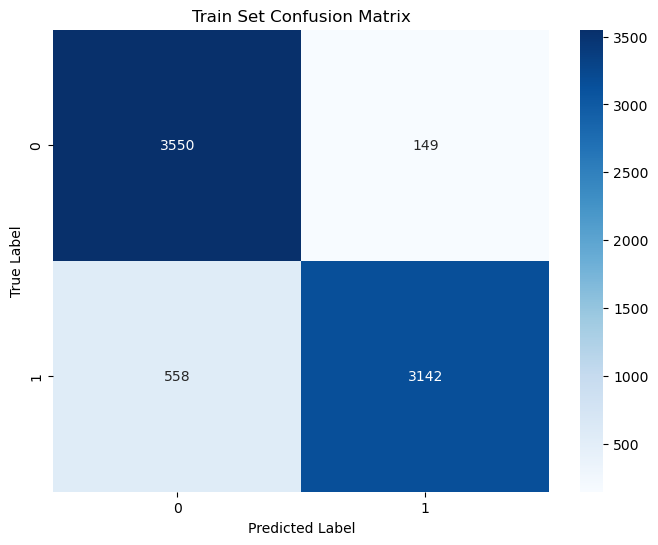


Validation Set Confusion Matrix:


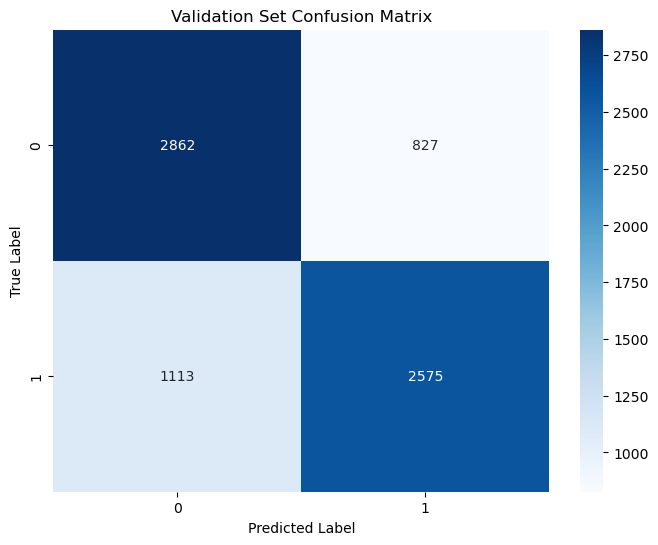


Test Set Confusion Matrix:


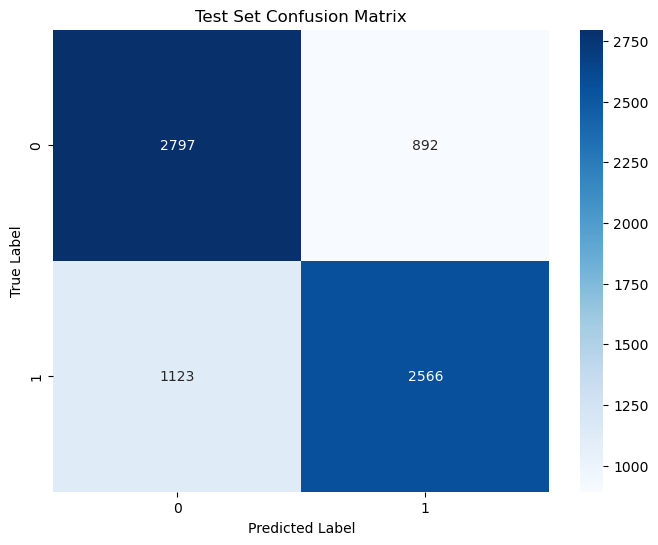

Train Set ROC Curve:


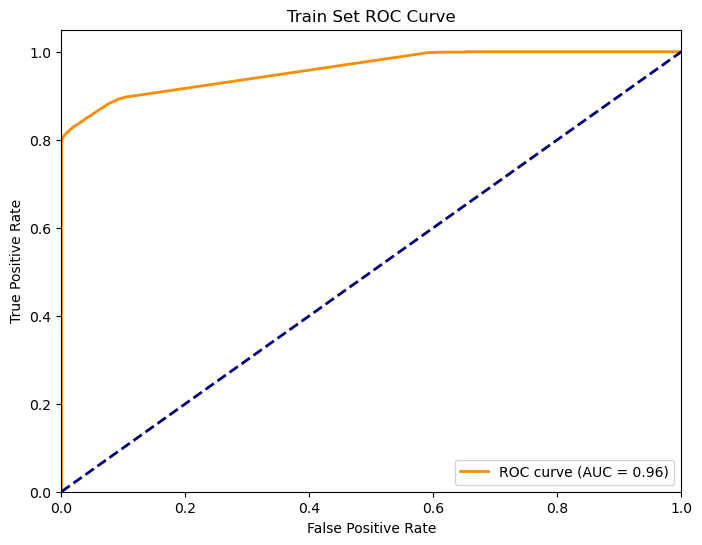

Validation Set ROC Curve:


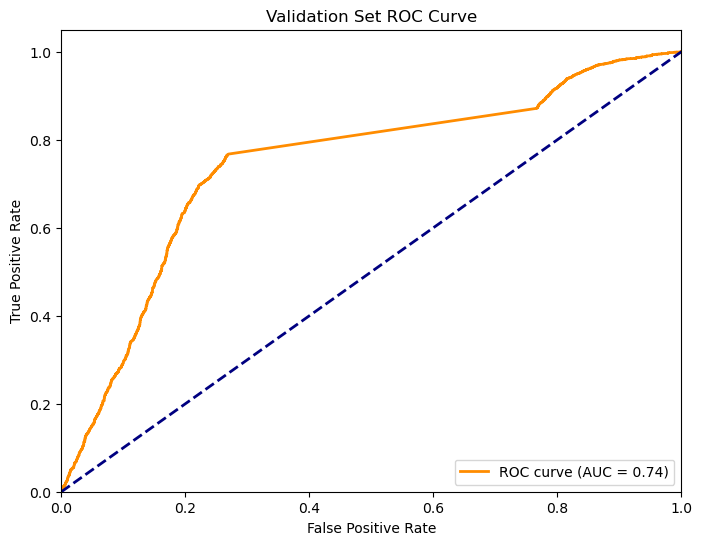

Test Set ROC Curve:


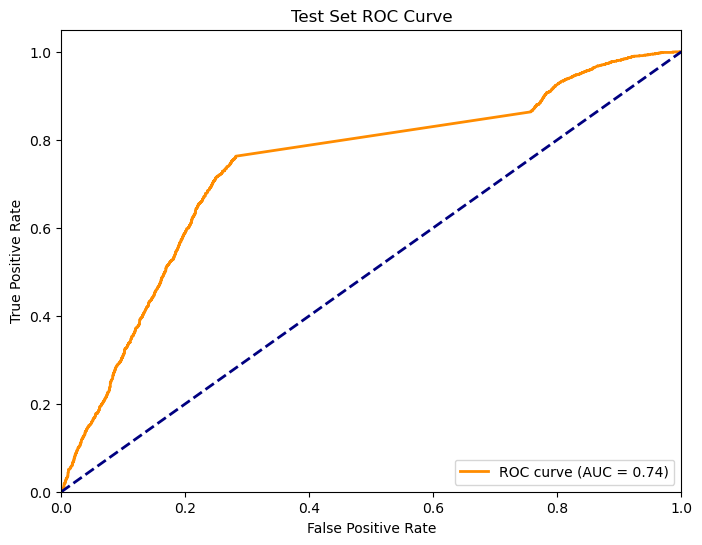

In [11]:
# Train and evaluate model
model, results = create_and_train_model(X, y)

In [12]:
# Print metrics
print("Train Set Metric:")
print(results['train_metrics'])
print("\nValidation Set Metrics:")
print(results['validation_metrics'])
print("\nTest Set Metrics:")
print(results['test_metrics'])
    
# Print AUC scores
print(f"Train Set AUC: {results['train_auc']:.3f}")
print(f"Validation Set AUC: {results['validation_auc']:.3f}")
print(f"Test Set AUC: {results['test_auc']:.3f}")

Train Set Metric:
              precision    recall  f1-score   support

           0       0.71      0.76      0.74      3689
           1       0.74      0.70      0.72      3689

    accuracy                           0.73      7378
   macro avg       0.73      0.73      0.73      7378
weighted avg       0.73      0.73      0.73      7378


Validation Set Metrics:
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      3689
           1       0.76      0.70      0.73      3688

    accuracy                           0.74      7377
   macro avg       0.74      0.74      0.74      7377
weighted avg       0.74      0.74      0.74      7377


Test Set Metrics:
              precision    recall  f1-score   support

           0       0.71      0.76      0.74      3689
           1       0.74      0.70      0.72      3689

    accuracy                           0.73      7378
   macro avg       0.73      0.73      0.73      7378
weighted avg